# 02 — Which pathway niches do Spp1+ macrophages live in?

Answers: *"What pathway hotspots are these Spp1 macrophages part of? Are they close to
hypoxic regions? Adenosine signaling? What metabolic regions do they lie in?"*

**Run `01_spp1_definition_and_abundance.py` first** — this script assumes `spp1_mac` /
`is_mac` are in `adata.obs` and that the definition passed validation.

### The design, and the one control that makes it mean something
Pathways are scored on **all cells**, then Gi\* finds each pathway's hotspot *as a property
of the tissue region* (a hypoxic zone, a lipid-handling zone). We then ask whether Spp1+
macrophages sit inside those zones. That matches the PDF's model: the niche comes first,
and monocytes stabilize into the SPP1 state inside it.

The trap: "Spp1+ macs are enriched in hypoxia hotspots **vs all cells**" is nearly
guaranteed to come out positive and would prove nothing — *macrophages in general* infiltrate
damaged/hypoxic tissue. That result is about macrophage-ness, not about the Spp1 state.

So every enrichment is computed against **two baselines**:

| Baseline | Question | Interpretation |
|---|---|---|
| **vs all cells** | Do Spp1+ macs live in this niche? | descriptive; confounded by mac infiltration |
| **vs Spp1- macs** | Is the *Spp1 state specifically* enriched here? | **the decisive test** |

The second restricts to the macrophage compartment and asks whether the Spp1+ *fraction of
macrophages* rises inside the hotspot. That isolates the state from the lineage. If the PDF's
model is right, hypoxia / oxidized-lipid / adenosine niches should be positive on **both**,
while a generic "macrophages go where damage is" effect shows up only on the first.

In [1]:
import re
import warnings
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

import scanpy as sc
import spatialdata as spd

from scipy.stats import norm, mannwhitneyu
from sklearn.neighbors import NearestNeighbors
from statsmodels.stats.multitest import multipletests

try:
    from spatialdata.transformations import get_transformation
except Exception:
    get_transformation = None

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 220)

: 

: 

## 1. Configuration

In [2]:
PROJ_DIR    = Path("/coh_labs/yunroseli/Jona/CAR-T")
ZARR_FILE   = PROJ_DIR / "data/zarr/fullDataset/processing_Zarr/1_C2l_annotated_CC"
PATHWAY_DIR = PROJ_DIR / "data/references/pathways"
OUT_DIR     = PROJ_DIR / "results/spp1_analysis"
FIG_DIR     = OUT_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

GMT_FILES = {
    "hallmark": PATHWAY_DIR / "mh.all.v2026.1.Mm.symbols.gmt",
    "reactome": PATHWAY_DIR / "m2.cp.reactome.v2026.1.Mm.symbols.gmt",
    "go_bp":    PATHWAY_DIR / "m5.go.bp.v2026.1.Mm.symbols.gmt",
    "curated":  PATHWAY_DIR / "m2.cp.v2026.1.Mm.symbols.gmt",
}

TISSUE_COL    = "tissue"
CELL_TYPE_COL = "c2l_consolidated"
MAC_LABELS    = ["M1_like_Mac", "M2_like_Mac", "Intermediate_Mac"]
SPP1_THRESHOLD = 2          # keep in sync with script 01

MICRONS_PER_PIXEL = 0.34    # from Hotspot_Abscopal_Comparison
APPLY_HIRES_SCALE = True

K_GI          = 50
ALPHA         = 0.05
MIN_CELLS     = 100
ENRICH_RADIUS_UM = 50
N_PERM        = 1000
MIN_MATCHED_GENES = 5
MIN_MACS_PER_TISSUE = 50    # below this, the mac-restricted test is not interpretable

# Smoke test: set to a few tissues to sanity-check before the full ~30-60 min run.
TISSUE_SUBSET = None        # e.g. ["RTCyPSCA_1_2", "CyPSCA_1_1"]

print("config ready ->", OUT_DIR)

config ready -> /coh_labs/yunroseli/Jona/CAR-T/results/spp1_analysis


## 2. Gi\* engine (inlined — the HPC kernel can't see local .py files)

Same math as `gistar_utils.py`, with one change: the kNN index is built **once per tissue**
and reused across all pathways. The neighbor graph depends only on coordinates, not on the
values being tested, so rebuilding it 56x per tissue was pure waste. This is what makes a
56-pathway x 32-tissue sweep finish in a reasonable time.

In [3]:
def get_tissue_scale_to_hires(sdata, tissue_name,
                              coordinate_system="downscale_to_hires",
                              shapes_suffix="_cell_boundaries"):
    shapes_key = f"{tissue_name}{shapes_suffix}"
    if get_transformation is None or shapes_key not in sdata.shapes:
        return 1.0
    try:
        tf = get_transformation(sdata.shapes[shapes_key], get_all=True)[coordinate_system]
        return float(tf.scale[0])
    except Exception as e:
        print(f"WARNING: no hires scale for {tissue_name} ({e}); using 1.0")
        return 1.0

def get_tissue_coords_um(adata, sdata, tissue_name):
    mask = adata.obs[TISSUE_COL].astype(str).eq(str(tissue_name)).values
    coords = np.asarray(adata.obsm["spatial"][mask], dtype=float)
    scale = get_tissue_scale_to_hires(sdata, tissue_name) if APPLY_HIRES_SCALE else 1.0
    return mask, coords * scale * MICRONS_PER_PIXEL, scale

def build_knn(coords_um, k=K_GI):
    """kNN index for Gi* — built once per tissue, reused for every pathway."""
    n = len(coords_um)
    nn = NearestNeighbors(n_neighbors=min(k + 1, n)).fit(coords_um)
    _, idx = nn.kneighbors(coords_um)
    return idx

def gi_star_from_idx(values, idx):
    """Getis-Ord Gi* z + BH-FDR q (hot/cold) given a precomputed binary kNN (self included)."""
    values = np.asarray(values, float)
    n = len(values)
    if np.nanstd(values) == 0:
        nanv = np.full(n, np.nan)
        return nanv, nanv, nanv
    local = values[idx].sum(axis=1)
    xbar, s, sw = values.mean(), values.std(ddof=0), idx.shape[1]
    denom = s * np.sqrt((n * sw - sw ** 2) / (n - 1))
    z = (local - xbar * sw) / denom
    return z, multipletests(norm.sf(z), method="fdr_bh")[1], multipletests(norm.cdf(z), method="fdr_bh")[1]

def near_mask_of(coords_um, hotspot_mask, radius_um=ENRICH_RADIUS_UM):
    """Cells whose nearest hotspot cell is within radius_um."""
    if hotspot_mask.sum() == 0:
        return np.zeros(len(coords_um), bool)
    nn = NearestNeighbors(n_neighbors=1).fit(coords_um[hotspot_mask])
    d, _ = nn.kneighbors(coords_um)
    return d.ravel() <= radius_um

def enrichment(target_mask, near_mask, universe_mask, n_perm=N_PERM, rng=0):
    """log2 enrichment of `target` among `near` cells, restricted to `universe`,
    vs a hypergeometric label-permutation null.

    universe = all cells      -> 'do Spp1+ macs live here?'
    universe = macrophages    -> 'is the Spp1 STATE enriched here, beyond mac infiltration?'
    """
    rng = np.random.default_rng(rng)
    tgt = np.asarray(target_mask, bool) & universe_mask
    near = np.asarray(near_mask, bool) & universe_mask
    n, n_t, n_near = int(universe_mask.sum()), int(tgt.sum()), int(near.sum())
    out = {"n_universe": n, "n_target": n_t, "n_near": n_near,
           "obs_frac": np.nan, "baseline_frac": np.nan, "log2_enrich": np.nan,
           "z": np.nan, "emp_p": np.nan}
    if n == 0 or n_t == 0 or n_near == 0:
        return out
    baseline = n_t / n
    obs = float(tgt[near].sum() / n_near)
    out["baseline_frac"], out["obs_frac"] = baseline, obs
    out["log2_enrich"] = float(np.log2(obs / baseline)) if obs > 0 else -np.inf
    null = rng.hypergeometric(n_t, n - n_t, n_near, size=n_perm) / n_near
    mu, sd = null.mean(), null.std(ddof=1)
    out["z"] = float((obs - mu) / sd) if sd > 0 else np.nan
    out["emp_p"] = float((np.sum(np.abs(null - mu) >= abs(obs - mu)) + 1) / (n_perm + 1))
    return out

def cliffs_delta(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    a, b = a[np.isfinite(a)], b[np.isfinite(b)]
    if not len(a) or not len(b):
        return np.nan
    return float(np.sign(a[:, None] - b[None, :]).sum() / (len(a) * len(b)))

print("engine ready")

engine ready


## 3. Load data + rebuild the Spp1 labels

In [4]:
sdata = spd.read_zarr(ZARR_FILE)
adata = sdata.tables["segmentation_counts"]

import scipy.sparse as sp
spp1_i = int(adata.var_names.get_loc("Spp1"))
_c = adata.layers["counts"][:, spp1_i]
spp1_counts = np.asarray(_c.todense()).ravel() if sp.issparse(_c) else np.asarray(_c).ravel()

ct = adata.obs[CELL_TYPE_COL].astype(str)
adata.obs["is_mac"]   = ct.isin(MAC_LABELS).values
adata.obs["spp1_mac"] = adata.obs["is_mac"].values & (spp1_counts >= SPP1_THRESHOLD)

print(f"macrophages: {int(adata.obs['is_mac'].sum()):,} | "
      f"Spp1+ macs: {int(adata.obs['spp1_mac'].sum()):,} "
      f"({100*adata.obs['spp1_mac'].sum()/adata.obs['is_mac'].sum():.1f}% of macs)")

macrophages: 81,565 | Spp1+ macs: 52,984 (65.0% of macs)


## 4. The pathway panel

Chosen against the PDF's hypothesis, and **verified to exist** in your 4 GMTs. Tiers map to
how directly each block tests the model:

- **T1_niche** — the mechanism itself: hypoxia, adenosine (CD39/CD73), oxidized-lipid /
  scavenger uptake, foam-cell / lipid storage, efferocytosis, glycolysis-lactate.
  *These are the ones the hypothesis stands or falls on.*
- **T2_amplifier** — FAO/PPAR, amino-acid & polyamine (the PDF's "reinforce, not initiate"),
  fibrosis/ECM/angiogenesis (the FAP+ immune-excluding niche).
- **T3_contrast** — IFN / inflammatory / p53 / apoptosis. These are the **discriminating
  controls**: if Spp1+ macs enrich in *everything* including these, the enrichment is a
  density artifact rather than niche specificity.

In [5]:
PANEL = {
    # ---- T1: the niche mechanism ----
    "Hypoxia_Hallmark":            ("HALLMARK_HYPOXIA", "T1_niche"),
    "Hypoxia_Response_GO":         ("GOBP_CELLULAR_RESPONSE_TO_HYPOXIA", "T1_niche"),
    "Hypoxia_Reactome":            ("REACTOME_CELLULAR_RESPONSE_TO_HYPOXIA", "T1_niche"),
    "HIF1a_Signaling_GO":          ("GOBP_HYPOXIA_INDUCIBLE_FACTOR_1ALPHA_SIGNALING_PATHWAY", "T1_niche"),
    "Adenosine_Metabolism_GO":     ("GOBP_ADENOSINE_METABOLIC_PROCESS", "T1_niche"),
    "AMP_Metabolism_GO":           ("GOBP_AMP_METABOLIC_PROCESS", "T1_niche"),
    "Nucleotide_Catabolism_GO":    ("GOBP_NUCLEOTIDE_CATABOLIC_PROCESS", "T1_niche"),
    "Purinergic_Signaling_GO":     ("GOBP_PURINERGIC_NUCLEOTIDE_RECEPTOR_SIGNALING_PATHWAY", "T1_niche"),
    "Purinergic_Receptors_Reactome": ("REACTOME_NUCLEOTIDE_LIKE_PURINERGIC_RECEPTORS", "T1_niche"),
    "oxLDL_Response_GO":           ("GOBP_CELLULAR_RESPONSE_TO_OXIDISED_LOW_DENSITY_LIPOPROTEIN_PARTICLE_STIMULUS", "T1_niche"),
    "ScavengerReceptor_Reactome":  ("REACTOME_BINDING_AND_UPTAKE_OF_LIGANDS_BY_SCAVENGER_RECEPTORS", "T1_niche"),
    "Lipid_Oxidation_GO":          ("GOBP_LIPID_OXIDATION", "T1_niche"),
    "LDL_Clearance_GO":            ("GOBP_LOW_DENSITY_LIPOPROTEIN_PARTICLE_CLEARANCE", "T1_niche"),
    "FoamCell_Mac_GO":             ("GOBP_MACROPHAGE_DERIVED_FOAM_CELL_DIFFERENTIATION", "T1_niche"),
    "FoamCell_GO":                 ("GOBP_FOAM_CELL_DIFFERENTIATION", "T1_niche"),
    "LipidDroplet_GO":             ("GOBP_LIPID_DROPLET_ORGANIZATION", "T1_niche"),
    "Cholesterol_Storage_GO":      ("GOBP_CHOLESTEROL_STORAGE", "T1_niche"),
    "Cholesterol_Homeostasis_Hallmark": ("HALLMARK_CHOLESTEROL_HOMEOSTASIS", "T1_niche"),
    "Cholesterol_Efflux_GO":       ("GOBP_CHOLESTEROL_EFFLUX", "T1_niche"),
    "Cholesterol_Import_GO":       ("GOBP_CHOLESTEROL_IMPORT", "T1_niche"),
    "ApoptoticCellClearance_GO":   ("GOBP_APOPTOTIC_CELL_CLEARANCE", "T1_niche"),
    "Engulfment_Apoptotic_GO":     ("GOBP_ENGULFMENT_OF_APOPTOTIC_CELL", "T1_niche"),
    "Phagocytosis_GO":             ("GOBP_PHAGOCYTOSIS", "T1_niche"),
    "Glycolysis_Hallmark":         ("HALLMARK_GLYCOLYSIS", "T1_niche"),
    "Lactate_Metabolism_GO":       ("GOBP_LACTATE_METABOLIC_PROCESS", "T1_niche"),
    # ---- T2: amplifiers / cooperating ----
    "FattyAcid_BetaOx_GO":         ("GOBP_FATTY_ACID_BETA_OXIDATION", "T2_amplifier"),
    "FattyAcid_Metabolism_Hallmark": ("HALLMARK_FATTY_ACID_METABOLISM", "T2_amplifier"),
    "Adipogenesis_Hallmark":       ("HALLMARK_ADIPOGENESIS", "T2_amplifier"),
    "LongChainFA_Import_GO":       ("GOBP_LONG_CHAIN_FATTY_ACID_IMPORT_INTO_CELL", "T2_amplifier"),
    "Glutamine_Metabolism_GO":     ("GOBP_GLUTAMINE_METABOLIC_PROCESS", "T2_amplifier"),
    "Arginine_Metabolism_GO":      ("GOBP_ARGININE_METABOLIC_PROCESS", "T2_amplifier"),
    "Polyamine_Biosynthesis_GO":   ("GOBP_POLYAMINE_BIOSYNTHETIC_PROCESS", "T2_amplifier"),
    "EMT_Hallmark":                ("HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION", "T2_amplifier"),
    "ECM_Organization_Reactome":   ("REACTOME_EXTRACELLULAR_MATRIX_ORGANIZATION", "T2_amplifier"),
    "Fibroblast_Activation_GO":    ("GOBP_FIBROBLAST_ACTIVATION", "T2_amplifier"),
    "Myofibroblast_GO":            ("GOBP_MYOFIBROBLAST_DIFFERENTIATION", "T2_amplifier"),
    "Angiogenesis_Hallmark":       ("HALLMARK_ANGIOGENESIS", "T2_amplifier"),
    "TGFb_Hallmark":               ("HALLMARK_TGF_BETA_SIGNALING", "T2_amplifier"),
    "Mac_Chemotaxis_GO":           ("GOBP_MACROPHAGE_CHEMOTAXIS", "T2_amplifier"),
    "Monocyte_Chemotaxis_GO":      ("GOBP_MONOCYTE_CHEMOTAXIS", "T2_amplifier"),
    # ---- T3: discriminating contrast ----
    "IFN_gamma_Hallmark":          ("HALLMARK_INTERFERON_GAMMA_RESPONSE", "T3_contrast"),
    "IFN_alpha_Hallmark":          ("HALLMARK_INTERFERON_ALPHA_RESPONSE", "T3_contrast"),
    "Inflammatory_Hallmark":       ("HALLMARK_INFLAMMATORY_RESPONSE", "T3_contrast"),
    "TNFa_NFkB_Hallmark":          ("HALLMARK_TNFA_SIGNALING_VIA_NFKB", "T3_contrast"),
    "P53_Hallmark":                ("HALLMARK_P53_PATHWAY", "T3_contrast"),
    "Apoptosis_Hallmark":          ("HALLMARK_APOPTOSIS", "T3_contrast"),
    "Complement_Hallmark":         ("HALLMARK_COMPLEMENT", "T3_contrast"),
    "ROS_Hallmark":                ("HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY", "T3_contrast"),
}
TIER_OF = {k: v[1] for k, v in PANEL.items()}
print(f"panel: {len(PANEL)} pathways "
      f"({sum(t=='T1_niche' for t in TIER_OF.values())} niche / "
      f"{sum(t=='T2_amplifier' for t in TIER_OF.values())} amplifier / "
      f"{sum(t=='T3_contrast' for t in TIER_OF.values())} contrast)")

panel: 48 pathways (25 niche / 15 amplifier / 8 contrast)


## 5. Score the panel (coverage check)

In [6]:
def read_gmt(path):
    out = {}
    with open(path) as f:
        for line in f:
            p = line.rstrip("\n").split("\t")
            if len(p) >= 3:
                out[p[0]] = p[2:]
    return out

all_gene_sets = {}
for coll, path in GMT_FILES.items():
    all_gene_sets.update(read_gmt(path))
print(f"loaded {len(all_gene_sets):,} gene sets")

available = set(adata.var_names.astype(str))
recs = []
for short, (gs_name, tier) in PANEL.items():
    genes = all_gene_sets.get(gs_name, [])
    matched = [g for g in genes if g in available]
    status = "scored"
    if gs_name not in all_gene_sets:
        status = "MISSING_FROM_GMT"
    elif len(matched) < MIN_MATCHED_GENES:
        status = f"SKIPPED(<{MIN_MATCHED_GENES})"
    else:
        sc.tl.score_genes(adata, gene_list=matched, score_name=f"{short}_score",
                          use_raw=False, random_state=0)
    recs.append({"short_name": short, "tier": tier, "gene_set": gs_name,
                 "n_in_gmt": len(genes), "n_matched": len(matched), "status": status})

coverage = pd.DataFrame(recs).sort_values(["tier", "short_name"])
coverage.to_csv(OUT_DIR / "pathway_coverage.csv", index=False)
score_cols = [f"{r.short_name}_score" for r in coverage.itertuples()
              if r.status == "scored" and f"{r.short_name}_score" in adata.obs.columns]
SHORT_OF = {f"{s}_score": s for s in PANEL}

print(f"\n{len(score_cols)}/{len(PANEL)} pathways scored")
bad = coverage[coverage.status != "scored"]
if len(bad):
    print("NOT scored:"); print(bad[["short_name", "status", "n_matched"]].to_string(index=False))
coverage

loaded 9,618 gene sets

48/48 pathways scored


,short_name,tier,gene_set,n_in_gmt,n_matched,status
5,AMP_Metabolism_GO,T1_niche,GOBP_AMP_METABOLIC_PROCESS,28,24,scored
4,Adenosine_Metabolism_GO,T1_niche,GOBP_ADENOSINE_METABOLIC_PROCESS,15,14,scored
20,ApoptoticCellClearance_GO,T1_niche,GOBP_APOPTOTIC_CELL_CLEARANCE,40,39,scored
18,Cholesterol_Efflux_GO,T1_niche,GOBP_CHOLESTEROL_EFFLUX,67,66,scored
17,Cholesterol_Homeostasis_Hallmark,T1_niche,HALLMARK_CHOLESTEROL_HOMEOSTASIS,71,70,scored
19,Cholesterol_Import_GO,T1_niche,GOBP_CHOLESTEROL_IMPORT,16,15,scored
16,Cholesterol_Storage_GO,T1_niche,GOBP_CHOLESTEROL_STORAGE,24,24,scored
21,Engulfment_Apoptotic_GO,T1_niche,GOBP_ENGULFMENT_OF_APOPTOTIC_CELL,12,12,scored
14,FoamCell_GO,T1_niche,GOBP_FOAM_CELL_DIFFERENTIATION,35,34,scored
13,FoamCell_Mac_GO,T1_niche,GOBP_MACROPHAGE_DERIVED_FOAM_CELL_DIFFERENTIATION,31,30,scored


## 6. Per-tissue Gi\* + Spp1 enrichment (the main loop)

For each tissue x pathway: Gi\* hotspot, then Spp1+ mac enrichment near it under **both**
baselines. Runtime ~30-60 min for all 32 tissues; use `TISSUE_SUBSET` to smoke-test first.

In [7]:
def parse_tissue(t):
    m = re.match(r"^(.*)_(\d+)_(\d+)$", str(t))
    return (m.group(1), int(m.group(2)), int(m.group(3))) if m else (None, None, None)

tissues = sorted(adata.obs[TISSUE_COL].astype(str).unique())
if TISSUE_SUBSET:
    tissues = [t for t in tissues if t in TISSUE_SUBSET]

rows = []
for ti, tname in enumerate(tissues, 1):
    mask, coords_um, scale = get_tissue_coords_um(adata, sdata, tname)
    n_cells = int(mask.sum())
    if n_cells < MIN_CELLS:
        print(f"skip {tname} ({n_cells} cells)"); continue

    obs_t = adata.obs.loc[mask]
    mac_u  = obs_t["is_mac"].values.astype(bool)
    spp1_u = obs_t["spp1_mac"].values.astype(bool)
    all_u  = np.ones(n_cells, bool)
    cond, loc, rep = parse_tissue(tname)

    if mac_u.sum() < MIN_MACS_PER_TISSUE:
        print(f"skip {tname}: only {int(mac_u.sum())} macrophages (< {MIN_MACS_PER_TISSUE})")
        continue

    idx = build_knn(coords_um, k=K_GI)          # built ONCE, reused for every pathway
    print(f"[{ti}/{len(tissues)}] {tname} n={n_cells:,} macs={int(mac_u.sum()):,} "
          f"spp1={int(spp1_u.sum()):,}", flush=True)

    for sc_col in score_cols:
        vals = obs_t[sc_col].astype(float).values
        if not np.isfinite(vals).all() or np.nanstd(vals) == 0:
            continue
        z, q_hot, _ = gi_star_from_idx(vals, idx)
        hot = (z > 0) & (q_hot < ALPHA)
        if hot.sum() == 0:
            continue
        near = near_mask_of(coords_um, hot, ENRICH_RADIUS_UM)

        e_all = enrichment(spp1_u, near, all_u)   # vs all cells   (descriptive)
        e_mac = enrichment(spp1_u, near, mac_u)   # vs Spp1- macs  (decisive)

        rows.append({
            "tissue": tname, "cond": cond, "tumor_loc": loc,
            "rt_group": "no_RT" if not cond.startswith("RT") else ("RT_direct" if loc == 1 else "RT_abscopal"),
            "group": f"{cond}_{loc}",
            "pathway": SHORT_OF[sc_col], "tier": TIER_OF[SHORT_OF[sc_col]],
            "n_cells": n_cells, "n_mac": int(mac_u.sum()), "n_spp1_mac": int(spp1_u.sum()),
            "pct_hot": 100 * hot.mean(), "mean_score": float(vals.mean()),
            "vsAll_log2": e_all["log2_enrich"], "vsAll_p": e_all["emp_p"], "vsAll_z": e_all["z"],
            "vsMac_log2": e_mac["log2_enrich"], "vsMac_p": e_mac["emp_p"], "vsMac_z": e_mac["z"],
            "vsMac_obs_frac": e_mac["obs_frac"], "vsMac_baseline_frac": e_mac["baseline_frac"],
        })

enrich = pd.DataFrame(rows)
for c in ["vsAll_log2", "vsMac_log2"]:
    enrich[c] = enrich[c].replace([np.inf, -np.inf], np.nan)
enrich.to_csv(OUT_DIR / "spp1_pathway_enrichment_long.csv", index=False)
print("\nenrich:", enrich.shape)
enrich.head()

[1/32] CyPSCA_1_1 n=108,895 macs=1,914 spp1=1,106
[2/32] CyPSCA_1_2 n=55,540 macs=1,148 spp1=1,013
[3/32] CyPSCA_1_3 n=33,085 macs=3,740 spp1=2,621
[4/32] CyPSCA_1_4 n=27,025 macs=1,337 spp1=1,199
[5/32] CyPSCA_2_1 n=86,108 macs=4,134 spp1=2,112
[6/32] CyPSCA_2_2 n=61,384 macs=2,163 spp1=1,355
[7/32] CyPSCA_2_3 n=67,945 macs=3,029 spp1=1,766
[8/32] CyPSCA_2_4 n=54,121 macs=2,836 spp1=1,937
[9/32] CyT72_1_2 n=34,108 macs=4,102 spp1=1,369
[10/32] CyT72_1_4 n=49,785 macs=4,471 spp1=3,101
[11/32] CyT72_2_3 n=66,876 macs=6,168 spp1=4,727
skip CyT72_2_4: only 12 macrophages (< 50)
[13/32] NoTx_1_1 n=44,929 macs=586 spp1=574
skip NoTx_1_2: only 4 macrophages (< 50)
skip NoTx_1_3: only 11 macrophages (< 50)
skip NoTx_1_4: only 20 macrophages (< 50)
skip NoTx_2_1: only 3 macrophages (< 50)
skip NoTx_2_2: only 44 macrophages (< 50)
[19/32] NoTx_2_3 n=109,371 macs=57 spp1=50
skip NoTx_2_4: only 7 macrophages (< 50)
[21/32] RTCyPSCA_1_2 n=28,637 macs=625 spp1=498
[22/32] RTCyPSCA_1_3 n=57,620 macs

,tissue,cond,tumor_loc,rt_group,group,pathway,tier,n_cells,n_mac,n_spp1_mac,pct_hot,mean_score,vsAll_log2,vsAll_p,vsAll_z,vsMac_log2,vsMac_p,vsMac_z,vsMac_obs_frac,vsMac_baseline_frac
0,CyPSCA_1_1,CyPSCA,1,no_RT,CyPSCA_1,AMP_Metabolism_GO,T1_niche,108895,1914,1106,6.983792,0.076341,-0.352612,0.000999,-14.437511,0.331619,0.000999,13.163680,0.727177,0.577847
1,CyPSCA_1_1,CyPSCA,1,no_RT,CyPSCA_1,Adenosine_Metabolism_GO,T1_niche,108895,1914,1106,3.082786,-0.036989,0.005045,0.831169,0.225013,0.073215,0.000999,4.176664,0.607930,0.577847
2,CyPSCA_1_1,CyPSCA,1,no_RT,CyPSCA_1,ApoptoticCellClearance_GO,T1_niche,108895,1914,1106,8.386060,0.116726,0.144498,0.000999,8.859612,-0.021759,0.000999,-4.272028,0.569198,0.577847
3,CyPSCA_1_1,CyPSCA,1,no_RT,CyPSCA_1,Cholesterol_Efflux_GO,T1_niche,108895,1914,1106,19.465540,0.036480,0.188829,0.000999,8.806289,-0.061789,0.000999,-7.814231,0.553622,0.577847
4,CyPSCA_1_1,CyPSCA,1,no_RT,CyPSCA_1,Cholesterol_Homeostasis_Hallmark,T1_niche,108895,1914,1106,16.797833,0.130810,-0.137537,0.000999,-8.336044,0.280562,0.000999,15.296274,0.701893,0.577847


## 7. The headline result: which niches hold Spp1+ macrophages?

Averaged over tissues, both baselines side by side, FDR-corrected across pathways.
**`vsMac_log2` is the column that matters** — `vsAll_log2` being high while `vsMac_log2`
sits at ~0 means "macrophages are there", not "Spp1+ macrophages are there".

In [8]:
summary = (enrich.groupby(["tier", "pathway"], observed=True)
           .agg(n_tissues=("tissue", "count"),
                vsAll_log2=("vsAll_log2", "mean"),
                vsMac_log2=("vsMac_log2", "mean"),
                vsMac_z=("vsMac_z", "mean"),
                pct_hot=("pct_hot", "mean"))
           .reset_index())

# Combine per-tissue permutation p's into one per pathway (median), then FDR across pathways.
med_p = enrich.groupby(["tier", "pathway"], observed=True)["vsMac_p"].median().reset_index(name="vsMac_p_med")
summary = summary.merge(med_p, on=["tier", "pathway"])
ok = summary["vsMac_p_med"].notna()
summary.loc[ok, "vsMac_q"] = multipletests(summary.loc[ok, "vsMac_p_med"], method="fdr_bh")[1]

# Consistency: in how many tissues does the mac-restricted enrichment point the same way?
consist = (enrich.assign(pos=lambda d: d["vsMac_log2"] > 0)
           .groupby(["tier", "pathway"], observed=True)["pos"].mean().reset_index(name="frac_tissues_pos"))
summary = summary.merge(consist, on=["tier", "pathway"])

summary = summary.sort_values(["tier", "vsMac_log2"], ascending=[True, False])
summary.to_csv(OUT_DIR / "spp1_pathway_enrichment_summary.csv", index=False)

print("=== Spp1+ macrophage enrichment near pathway hotspots ===")
print("   vsAll = vs all cells (confounded) | vsMac = vs Spp1- macs (decisive)\n")
print(summary.round(3).to_string(index=False))

print("\n--- STRONGEST niches (mac-restricted, consistent across tissues) ---")
hits = summary[(summary["vsMac_log2"] > 0) & (summary["vsMac_q"] < 0.05) &
               (summary["frac_tissues_pos"] >= 0.7)].sort_values("vsMac_log2", ascending=False)
print(hits[["tier", "pathway", "vsMac_log2", "vsMac_q", "frac_tissues_pos"]].round(3).to_string(index=False)
      if len(hits) else "  none passed - see the caveat in section 9")

=== Spp1+ macrophage enrichment near pathway hotspots ===
   vsAll = vs all cells (confounded) | vsMac = vs Spp1- macs (decisive)

        tier                          pathway  n_tissues  vsAll_log2  vsMac_log2  vsMac_z  pct_hot  vsMac_p_med  vsMac_q  frac_tissues_pos
    T1_niche                 LDL_Clearance_GO         25       0.352       0.214   14.642    2.769        0.001    0.001             0.960
    T1_niche                AMP_Metabolism_GO         25       0.205       0.190   17.124   16.640        0.001    0.001             1.000
    T1_niche               Lipid_Oxidation_GO         25       0.137       0.190   15.611    8.321        0.001    0.001             1.000
    T1_niche              Glycolysis_Hallmark         25       0.152       0.158   15.221   24.234        0.001    0.001             1.000
    T1_niche                  LipidDroplet_GO         25       0.227       0.152   12.095    2.703        0.001    0.001             0.920
    T1_niche                 Hypoxi

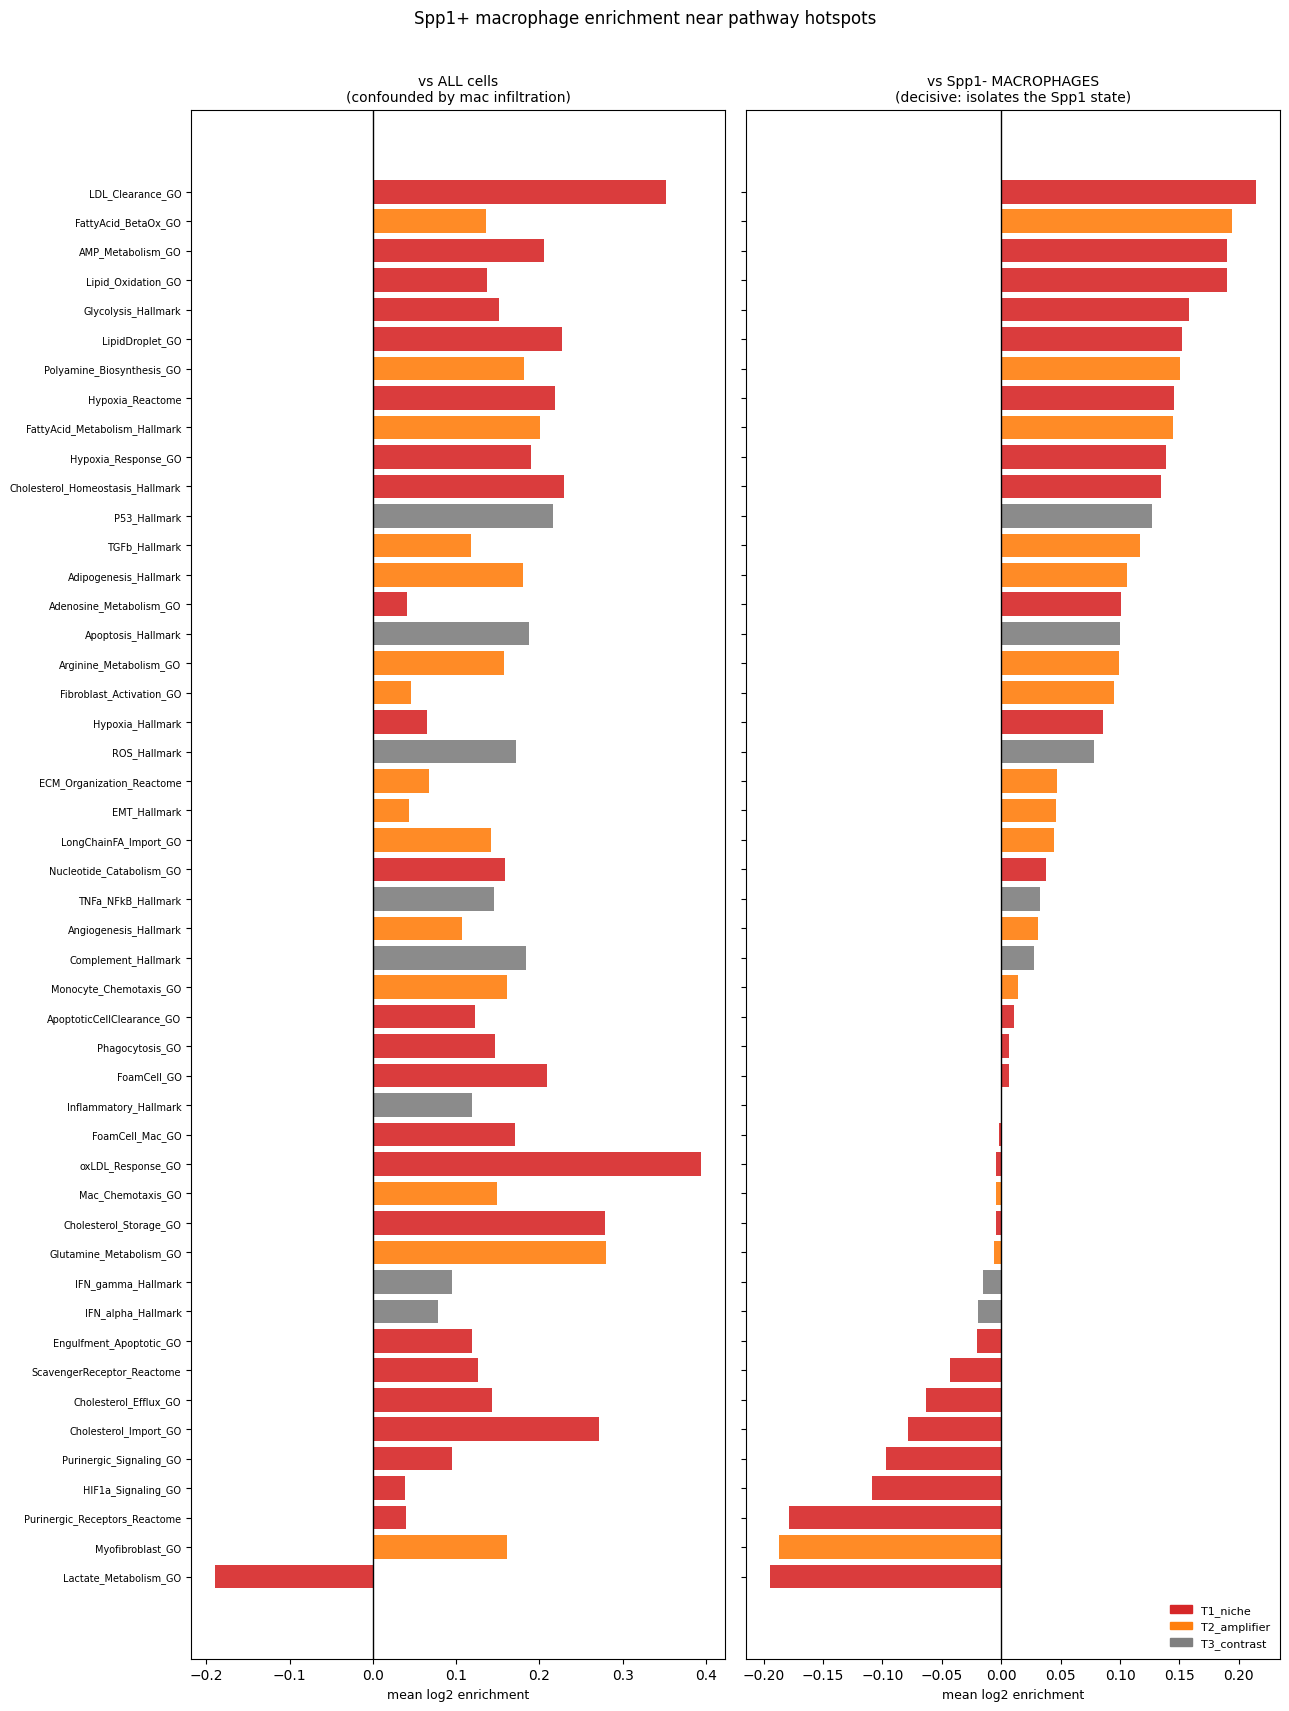

In [9]:
# Side-by-side barh: the two baselines. Divergence between them IS the message.
plot_df = summary.sort_values("vsMac_log2")
y = np.arange(len(plot_df))
tier_c = {"T1_niche": "#d62728", "T2_amplifier": "#ff7f0e", "T3_contrast": "#7f7f7f"}
fig, axes = plt.subplots(1, 2, figsize=(13, 0.30 * len(plot_df) + 2.5), sharey=True)
for ax, col, title in zip(axes, ["vsAll_log2", "vsMac_log2"],
                          ["vs ALL cells\n(confounded by mac infiltration)",
                           "vs Spp1- MACROPHAGES\n(decisive: isolates the Spp1 state)"]):
    ax.barh(y, plot_df[col].values, color=[tier_c[t] for t in plot_df["tier"]], alpha=0.9)
    ax.axvline(0, color="k", lw=1)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("mean log2 enrichment", fontsize=9)
axes[0].set_yticks(y); axes[0].set_yticklabels(plot_df["pathway"], fontsize=7)
handles = [plt.Rectangle((0, 0), 1, 1, color=c, label=t) for t, c in tier_c.items()]
axes[1].legend(handles=handles, fontsize=8, loc="lower right", frameon=False)
fig.suptitle("Spp1+ macrophage enrichment near pathway hotspots", y=1.01, fontsize=12)
fig.tight_layout(); fig.savefig(FIG_DIR / "spp1_pathway_enrichment.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)

## 8. Does RT change the niche coupling?

The PDF's claim is that **radiation builds the niche**. If so, the mac-restricted enrichment
in hypoxia / oxidized-lipid / adenosine hotspots should be **stronger in irradiated tissue**
— and the RT_abscopal vs no_RT contrast tests whether the *unirradiated* tumor also
reorganizes, which is the abscopal claim in your project data.

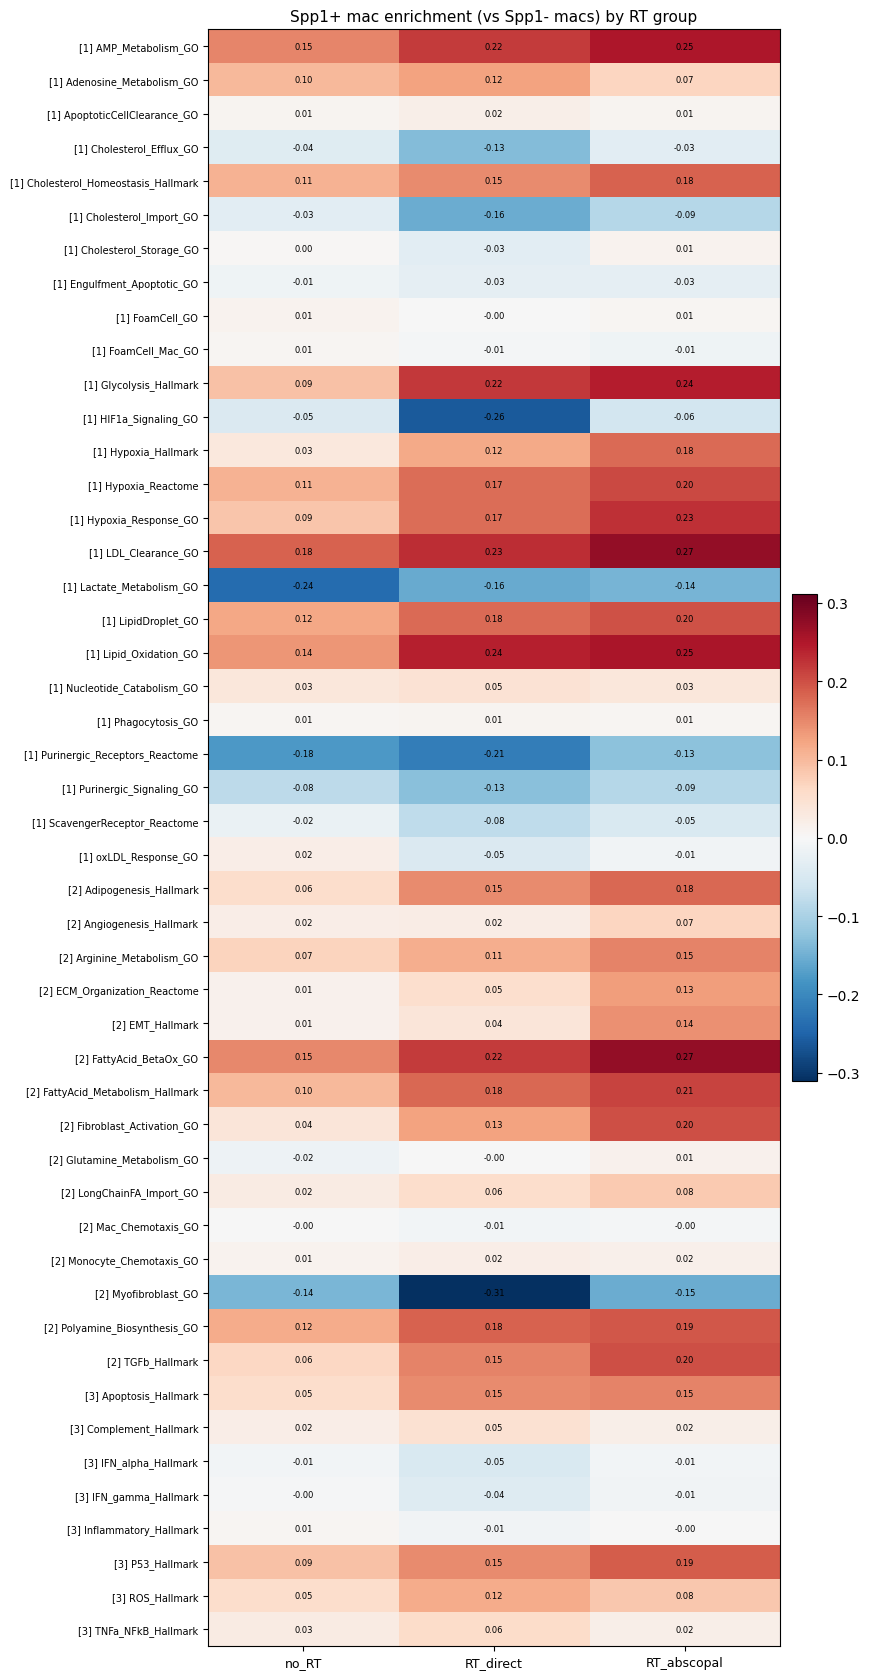

--- T1 niche coupling: RT contrasts (replicate-level; n is small, read effect sizes) ---
                         pathway                 contrast  mean_a  mean_b   diff  cliffs_delta  mwu_p
             Glycolysis_Hallmark     RT_abscopal vs no_RT   0.244   0.091  0.153         0.415  0.208
                Hypoxia_Hallmark     RT_abscopal vs no_RT   0.176   0.033  0.144         0.446  0.173
             Hypoxia_Response_GO     RT_abscopal vs no_RT   0.227   0.086  0.141         0.477  0.143
              Lipid_Oxidation_GO     RT_abscopal vs no_RT   0.254   0.138  0.116         0.323  0.336
               AMP_Metabolism_GO     RT_abscopal vs no_RT   0.250   0.153  0.098         0.262  0.443
                Hypoxia_Reactome     RT_abscopal vs no_RT   0.205   0.107  0.097         0.354  0.289
           Lactate_Metabolism_GO     RT_abscopal vs no_RT  -0.144  -0.240  0.096         0.455  0.180
                LDL_Clearance_GO     RT_abscopal vs no_RT   0.274   0.183  0.090         0.077 

In [10]:
piv = (enrich.groupby(["tier", "pathway", "rt_group"], observed=True)["vsMac_log2"]
       .mean().unstack("rt_group"))
piv = piv.reindex(columns=[c for c in ["no_RT", "RT_direct", "RT_abscopal"] if c in piv.columns])
piv.to_csv(OUT_DIR / "spp1_pathway_enrichment_by_rt_group.csv")

data = piv.values.astype(float)
vmax = np.nanmax(np.abs(data)) or 1.0
fig, ax = plt.subplots(figsize=(1.6 * data.shape[1] + 4, 0.30 * data.shape[0] + 2.5))
im = ax.imshow(data, cmap="RdBu_r", norm=TwoSlopeNorm(0, -vmax, vmax), aspect="auto")
ax.set_xticks(range(data.shape[1])); ax.set_xticklabels(piv.columns, fontsize=9)
ax.set_yticks(range(data.shape[0]))
ax.set_yticklabels([f"[{t[0][1]}] {t[1]}" for t in piv.index], fontsize=7)
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        if np.isfinite(data[i, j]):
            ax.text(j, i, f"{data[i,j]:.2f}", ha="center", va="center", fontsize=6)
ax.set_title("Spp1+ mac enrichment (vs Spp1- macs) by RT group", fontsize=11)
fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
fig.tight_layout(); fig.savefig(FIG_DIR / "spp1_enrichment_by_rt_group.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)

# Replicate-level contrasts on the T1 niche pathways.
rows = []
for pth, sub in enrich[enrich["tier"] == "T1_niche"].groupby("pathway", observed=True):
    for g1, g2 in [("RT_direct", "no_RT"), ("RT_abscopal", "no_RT"), ("RT_direct", "RT_abscopal")]:
        a = sub.loc[sub["rt_group"] == g1, "vsMac_log2"].dropna().values
        b = sub.loc[sub["rt_group"] == g2, "vsMac_log2"].dropna().values
        if len(a) < 2 or len(b) < 2:
            continue
        rows.append({"pathway": pth, "contrast": f"{g1} vs {g2}",
                     "mean_a": a.mean(), "mean_b": b.mean(), "diff": a.mean() - b.mean(),
                     "cliffs_delta": cliffs_delta(a, b),
                     "mwu_p": mannwhitneyu(a, b, alternative="two-sided").pvalue})
rt_contrasts = pd.DataFrame(rows)
rt_contrasts.to_csv(OUT_DIR / "spp1_niche_rt_contrasts.csv", index=False)
print("--- T1 niche coupling: RT contrasts (replicate-level; n is small, read effect sizes) ---")
print(rt_contrasts.sort_values(["contrast", "diff"], ascending=[True, False]).round(3).to_string(index=False))

## 9. How to read this — and the caveat that decides it

In [11]:
print(f"""
==================== SUMMARY — report these back ====================
Pathways scored     : {len(score_cols)}/{len(PANEL)}
Tissues analyzed    : {enrich['tissue'].nunique()}
Spp1 threshold      : >= {SPP1_THRESHOLD} UMI | cell types: {CELL_TYPE_COL}
Enrichment radius   : {ENRICH_RADIUS_UM} um | Gi* k={K_GI}, FDR alpha={ALPHA}

Top 5 niches by mac-restricted enrichment:
{summary.nlargest(5, 'vsMac_log2')[['pathway','tier','vsMac_log2','vsMac_q','frac_tissues_pos']].round(3).to_string(index=False)}

HOW TO READ IT
 - vsMac_log2 > 0 AND q < 0.05 AND frac_tissues_pos >= 0.7
     -> the Spp1 STATE (not just macrophages) concentrates in that niche.
 - vsAll_log2 >> 0 but vsMac_log2 ~ 0
     -> macrophages infiltrate there; the Spp1 state adds nothing. NOT evidence for the model.
 - T3_contrast pathways scoring as high as T1_niche
     -> the enrichment is non-specific (a density/patchiness artifact). Treat T1 hits as
        unproven until T3 is visibly flatter. T3 is the control that earns the T1 claim.

THE CAVEAT THAT DECIDES THIS ANALYSIS
 Pathway scores and the Spp1 call come from the SAME transcriptome. A macrophage that is
 Spp1-high also tends to be Apoe/Trem2/lipid-high, so it can raise the local lipid-pathway
 score itself -> the "hotspot" may be partly MADE of the Spp1+ macs we then find enriched in
 it. That is circular. The mac-restricted baseline does not fix this on its own.
 Script 03 addresses it directly by recomputing niche scores with macrophages EXCLUDED
 (niche defined by tumor/stromal/endothelial cells only) - if the enrichment survives that,
 it is real. Treat section 7 as a strong lead, not a conclusion, until then.
=====================================================================
""")


==================== SUMMARY — report these back ====================
Pathways scored     : 48/48
Tissues analyzed    : 25
Spp1 threshold      : >= 2 UMI | cell types: c2l_consolidated
Enrichment radius   : 50 um | Gi* k=50, FDR alpha=0.05

Top 5 niches by mac-restricted enrichment:
            pathway         tier  vsMac_log2  vsMac_q  frac_tissues_pos
   LDL_Clearance_GO     T1_niche       0.214    0.001              0.96
FattyAcid_BetaOx_GO T2_amplifier       0.194    0.001              0.92
  AMP_Metabolism_GO     T1_niche       0.190    0.001              1.00
 Lipid_Oxidation_GO     T1_niche       0.190    0.001              1.00
Glycolysis_Hallmark     T1_niche       0.158    0.001              1.00

HOW TO READ IT
 - vsMac_log2 > 0 AND q < 0.05 AND frac_tissues_pos >= 0.7
     -> the Spp1 STATE (not just macrophages) concentrates in that niche.
 - vsAll_log2 >> 0 but vsMac_log2 ~ 0
     -> macrophages infiltrate there; the Spp1 state adds nothing. NOT evidence for the model.
 